# Object Detection with YOLOv8 — Inference Guide

This notebook walks through running inference with the `YOLODetector` class on single images, directories, and how to visualize and interpret results.

**Classes detected:**
| ID | Name | Color in images |
|----|------|-----------------|
| 0 | ball | Red circle |
| 1 | box | Green rectangle |
| 2 | triangle | Red triangle |

---

## 1. Setup

Make sure dependencies are installed and the project root is on the Python path.

In [1]:
import subprocess, sys

# Install dependencies if needed
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                       "ultralytics", "opencv-python", "numpy", "matplotlib", "PyYAML"])

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


0

In [2]:
import sys
from pathlib import Path

# Add project root to path so we can import from src/
PROJECT_ROOT = Path(".").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from src.detector import YOLODetector
from src.utils import draw_detections

print(f"Project root: {PROJECT_ROOT}")
print("Imports OK")

Project root: /Users/juanbraga/devel/VibeCodedCV
Imports OK


---
## 2. Load the detector

`YOLODetector` wraps a YOLOv8 model. Two weight options:

- **`yolov8n.pt`** — pretrained on COCO (80 classes, downloaded automatically on first use)
- **`outputs/training/yolo_synthetic/weights/best.pt`** — fine-tuned on our 3-class synthetic dataset (use this after running `make train`)

In [3]:
WEIGHTS = "yolov8n.pt"
# WEIGHTS = "outputs/training/yolo_synthetic/weights/best.pt"  # use after training

detector = YOLODetector(
    weights=WEIGHTS,
    conf=0.5,   # minimum confidence score to keep a detection
    iou=0.45,   # IoU threshold for non-maximum suppression
)

print(f"Model loaded: {WEIGHTS}")
print(f"Classes: {detector.class_names}")

Model loaded: yolov8n.pt
Classes: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboa

---
## 3. Single image inference

`detect_image()` returns the original image as a NumPy array and a list of detection dictionaries.

Each detection contains:
```python
{
    "bbox":       [x1, y1, x2, y2],  # pixel coordinates
    "confidence": 0.87,
    "class_id":   1,
    "class_name": "box"
}
```

In [6]:
IMAGE_PATH = "data/images/test/dogandmontague2.jpg" 

image, detections = detector.detect_image(IMAGE_PATH)

print(f"Image shape : {image.shape}  (H x W x C)")
print(f"Detections  : {len(detections)}\n")
for d in detections:
    x1, y1, x2, y2 = [int(v) for v in d["bbox"]]
    print(f"  {d['class_name']:10s}  conf={d['confidence']:.2f}  bbox=({x1},{y1}) → ({x2},{y2})")

Image shape : (1152, 2048, 3)  (H x W x C)
Detections  : 3

  bicycle     conf=0.92  bbox=(258,88) → (1331,977)
  dog         conf=0.84  bbox=(1279,476) → (1567,984)
  person      conf=0.60  bbox=(11,318) → (50,412)


### Visualize the result

`draw_detections()` overlays bounding boxes and labels directly on a copy of the image.

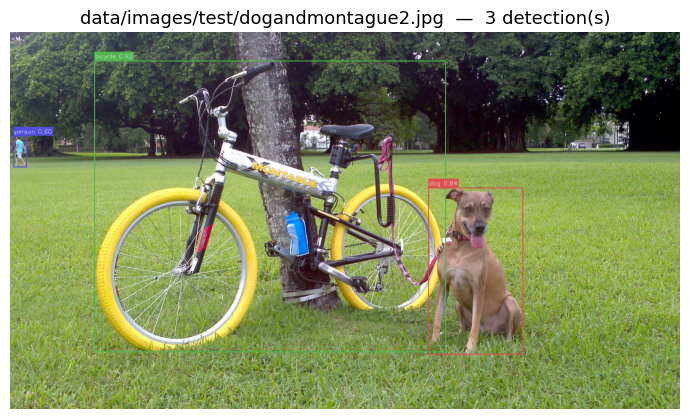

In [7]:
def show(img_bgr, title=""):
    """Display a BGR OpenCV image inline using matplotlib."""
    rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(7, 7))
    plt.imshow(rgb)
    plt.axis("off")
    if title:
        plt.title(title, fontsize=13)
    plt.tight_layout()
    plt.show()

annotated = draw_detections(image.copy(), detections)
show(annotated, f"{IMAGE_PATH}  —  {len(detections)} detection(s)")

---
## 4. Adjusting confidence and IoU thresholds

- **`conf`** — detections below this score are discarded. Lower = more detections, more false positives.
- **`iou`** — controls how aggressively overlapping boxes are merged. Lower = fewer boxes kept.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
conf_values = [0.3, 0.5, 0.8]

for ax, conf in zip(axes, conf_values):
    det = YOLODetector(weights=WEIGHTS, conf=conf, iou=0.45)
    img, dets = det.detect_image(IMAGE_PATH)
    annotated = draw_detections(img.copy(), dets)
    rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    ax.imshow(rgb)
    ax.set_title(f"conf={conf}  →  {len(dets)} detection(s)", fontsize=12)
    ax.axis("off")

plt.suptitle("Effect of confidence threshold", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Batch inference on a directory

Run the detector on every image in a folder and display a summary grid.

In [ ]:
TEST_DIR = Path("data/images/test")
image_paths = sorted(TEST_DIR.glob("*.jpg"))

results = []
for p in image_paths:
    img, dets = detector.detect_image(p)
    results.append((p, img, dets))
    print(f"  {p.name}: {len(dets)} detection(s)")

print(f"\nTotal images processed: {len(results)}")

In [ ]:
cols = 5
rows = (len(results) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
axes = axes.flatten()

for ax, (path, img, dets) in zip(axes, results):
    annotated = draw_detections(img.copy(), dets)
    rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    ax.imshow(rgb)
    ax.set_title(f"{path.name}\n{len(dets)} det.", fontsize=8)
    ax.axis("off")

for ax in axes[len(results):]:
    ax.axis("off")

plt.suptitle("Batch inference — test split", fontsize=13)
plt.tight_layout()
plt.show()

---
## 6. Filter detections by class

You can post-filter the detection list by `class_name` or `class_id` without re-running the model.

In [ ]:
image, detections = detector.detect_image("data/images/test/test_0000.jpg")

# Keep only a specific class
TARGET_CLASS = "ball"   # change to "box" or "triangle"
filtered = [d for d in detections if d["class_name"] == TARGET_CLASS]

print(f"All detections  : {len(detections)}")
print(f"'{TARGET_CLASS}' only : {len(filtered)}")

annotated = draw_detections(image.copy(), filtered)
show(annotated, f"Filtered to '{TARGET_CLASS}' only")

---
## 7. Inference on a raw NumPy frame

Use `detect_frame()` when your image already lives in memory (e.g. from a camera capture or video pipeline). It accepts a BGR NumPy array directly — no file path needed.

In [ ]:
# Simulate reading a frame from a camera / video
frame = cv2.imread("data/images/test/test_0001.jpg")

# Detect directly on the NumPy array
detections = detector.detect_frame(frame)

print(f"Detections: {len(detections)}")
for d in detections:
    print(f"  {d['class_name']}  conf={d['confidence']:.2f}")

annotated = draw_detections(frame.copy(), detections)
show(annotated, "detect_frame() on in-memory NumPy array")

---
## 8. Save results to disk

`save_results()` writes three files per image: an annotated JPEG, a plain-text summary, and a JSON file with all detection data.

In [ ]:
from src.utils import save_results
import json

image, detections = detector.detect_image("data/images/test/test_0000.jpg")

save_results(
    image=image,
    detections=detections,
    output_dir="outputs/detections",
    stem="demo_test_0000",
    save_image=True,   # writes demo_test_0000_detected.jpg
    save_txt=True,     # writes demo_test_0000.txt
    save_json=True,    # writes demo_test_0000.json
)

# Preview the saved JSON
json_path = Path("outputs/detections/demo_test_0000.json")
data = json.loads(json_path.read_text())
print(json.dumps(data, indent=2))

---
## 9. Detection statistics across the test set

Count how many times each class was detected across all test images.

In [ ]:
from collections import Counter

class_counts = Counter()
conf_scores = []

for _, _, dets in results:
    for d in dets:
        class_counts[d["class_name"]] += 1
        conf_scores.append(d["confidence"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart — detections per class
classes = list(class_counts.keys())
counts = list(class_counts.values())
colors = ["#e05050", "#50b050", "#5050e0"][:len(classes)]
ax1.bar(classes, counts, color=colors, edgecolor="white", linewidth=1.2)
ax1.set_title("Detections per class", fontsize=12)
ax1.set_ylabel("Count")
for i, (c, v) in enumerate(zip(classes, counts)):
    ax1.text(i, v + 0.2, str(v), ha="center", fontsize=11, fontweight="bold")

# Histogram — confidence distribution
ax2.hist(conf_scores, bins=15, color="#5588cc", edgecolor="white")
ax2.set_title("Confidence score distribution", fontsize=12)
ax2.set_xlabel("Confidence")
ax2.set_ylabel("Frequency")
ax2.axvline(detector.conf, color="red", linestyle="--", label=f"threshold ({detector.conf})")
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\nTotal detections : {sum(counts)}")
print(f"Mean confidence  : {sum(conf_scores)/len(conf_scores):.3f}" if conf_scores else "No detections.")

---
## Quick reference

| Method | Input | Returns |
|--------|-------|---------|
| `detector.detect_image(path)` | file path | `(np.ndarray, list[dict])` |
| `detector.detect_frame(array)` | BGR NumPy array | `list[dict]` |
| `detector.detect_video(path)` | video file path | streams annotated frames |
| `draw_detections(image, dets)` | BGR image + detections | annotated BGR image |
| `save_results(image, dets, ...)` | image + detections | writes JPEG / TXT / JSON |

**Tip:** switch to your fine-tuned weights by changing `WEIGHTS` in cell 2 to  
`"outputs/training/yolo_synthetic/weights/best.pt"` after running `make train`.